In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.001percent_8classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/__results__.html
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.01percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.005percent_8classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.05percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.1percent_8classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/__resultx__.html
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.1percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.001percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/__notebook__.ipynb
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.005percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/__output__.json
/kaggle/input/creating-a-smaller-dataset-for-ciciot2

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# Dataset folder
DATA_DIR = "/kaggle/input/creating-a-smaller-dataset-for-ciciot2023"

# Load only 2-class datasets
csv_files = [f for f in os.listdir(DATA_DIR) if "2classes" in f and f.endswith(".csv")]
print(f"Found {len(csv_files)} CSVs: {csv_files}")

df_list = []
for file in tqdm(csv_files):
    path = os.path.join(DATA_DIR, file)
    df_list.append(pd.read_csv(path))

df = pd.concat(df_list, ignore_index=True)
print("Combined shape:", df.shape)


Found 5 CSVs: ['0.05percent_2classes.csv', '0.005percent_2classes.csv', '0.1percent_2classes.csv', '0.01percent_2classes.csv', '0.001percent_2classes.csv']


100%|██████████| 5/5 [00:41<00:00,  8.23s/it]


Combined shape: (7749482, 47)


In [3]:
# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Replace infinite values and fill NaNs
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# Rename label column for convenience
df = df.rename(columns={"benign": "is_benign"})

# Convert boolean to text for clarity
df["label"] = df["is_benign"].apply(lambda x: "BENIGN" if x else "ATTACK")

print(df["label"].value_counts())


label
ATTACK    7567185
BENIGN     182297
Name: count, dtype: int64


In [4]:
# Split dataset into Benign and Attack
df_benign = df[df["label"] == "BENIGN"]
df_attack = df[df["label"] == "ATTACK"]

# Print class sizes
print("BENIGN samples:", len(df_benign))
print("ATTACK samples:", len(df_attack))

# Downsample majority (Attack) to match Benign
df_attack_down = resample(df_attack,
                          replace=False,
                          n_samples=len(df_benign),
                          random_state=42)

# Combine into balanced dataset
df_balanced = pd.concat([df_benign, df_attack_down])

print("Class counts after balancing:")
print(df_balanced["label"].value_counts())


BENIGN samples: 182297
ATTACK samples: 7567185
Class counts after balancing:
label
BENIGN    182297
ATTACK    182297
Name: count, dtype: int64


In [5]:
X = df_balanced.drop(columns=["label", "is_benign", "protocol_type"])  # drop label + bool + protocol
y = df_balanced["label"]

# Encode labels (BENIGN→0, ATTACK→1)
le = LabelEncoder()
y = le.fit_transform(y)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(128,64,32),
                                   activation="relu",
                                   solver="adam",
                                   max_iter=50,
                                   batch_size=256,
                                   learning_rate="adaptive",
                                   early_stopping=True,
                                   random_state=42)
}

for name, model in models.items():
    print("="*80)
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print("Training complete!")

    y_pred = model.predict(X_test)

    print(f"\n{name} - RESULTS:")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


Training Logistic Regression...
Training complete!

Logistic Regression - RESULTS:
Accuracy : 0.9875
Precision: 0.981
Recall   : 0.9942
F1 Score : 0.9876

Classification Report:
              precision    recall  f1-score   support

      ATTACK       0.99      0.98      0.99     36460
      BENIGN       0.98      0.99      0.99     36459

    accuracy                           0.99     72919
   macro avg       0.99      0.99      0.99     72919
weighted avg       0.99      0.99      0.99     72919

Training Random Forest...
Training complete!

Random Forest - RESULTS:
Accuracy : 0.9968
Precision: 0.9938
Recall   : 0.9999
F1 Score : 0.9968

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      0.99      1.00     36460
      BENIGN       0.99      1.00      1.00     36459

    accuracy                           1.00     72919
   macro avg       1.00      1.00      1.00     72919
weighted avg       1.00      1.00      1.00     72919

T

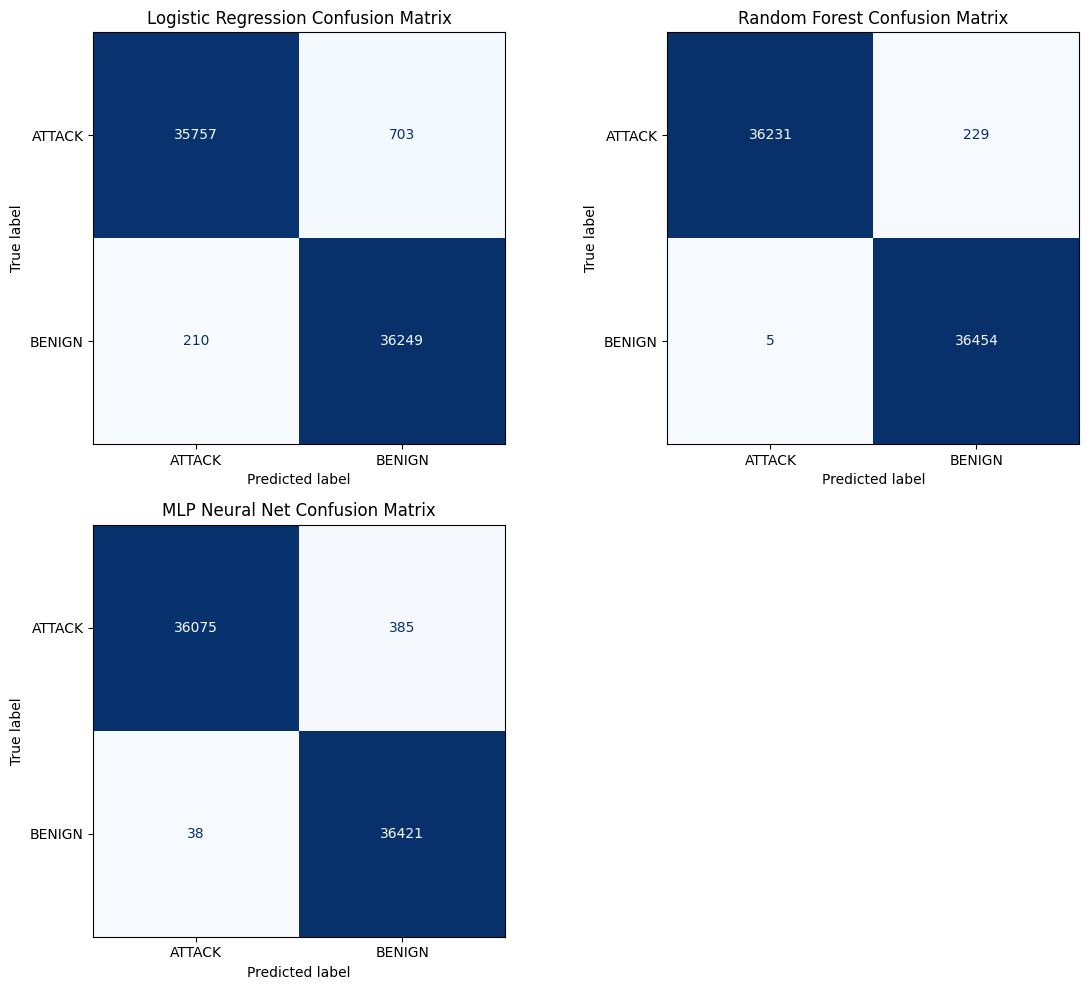

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Plot confusion matrices for all models
plt.figure(figsize=(12, 10))

for i, (name, model) in enumerate(models.items(), 1):
    # Predict on test data
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Display
    plt.subplot(2, 2, i)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", values_format="d", ax=plt.gca(), colorbar=False)
    plt.title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()
